In [1]:
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")

SAVE_DIR = 'data/quantization/'
import os

TensorFlow version: 2.10.1


# ============================================
# 1. LOAD AND PREPROCESS MNIST DATASET
# ============================================

In [2]:
print("Loading MNIST dataset...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize and reshape
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0


x_train = tf.expand_dims(x_train, axis=-1)
x_test = tf.expand_dims(x_test, axis=-1)

# Add channel dimension (28, 28, 1)
# x_train = np.expand_dims(x_train, axis=-1)
# x_test = np.expand_dims(x_test, axis=-1)

# Convert labels to categorical
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Training labels shape: {y_train.shape}")

Loading MNIST dataset...
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)
Training labels shape: (60000, 10)


# ============================================
# 2. CREATE YOUR CNN ARCHITECTURE
# ============================================

In [3]:
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, Dropout, Flatten, Dense

def create_cnn_model():
    model = Sequential([
        Input(shape=(28, 28, 1)),
        Conv2D(32, (3, 3), padding='same', activation='relu', name='conv1'),
        MaxPool2D(pool_size=(2, 2), strides=(2, 2), name='pool1'),
        Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2'),
        MaxPool2D(pool_size=(2, 2), strides=(2, 2), name='pool2'),
        Dropout(0.25, name='dropout'),
        Flatten(name='flatten'),
        Dense(128, activation='relu', name='dense1'),
        Dense(10, activation='softmax', name='output')
    ])
    return model

# Create and compile model
model = create_cnn_model()

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1 (Conv2D)              (None, 28, 28, 32)        320       
                                                                 
 pool1 (MaxPooling2D)        (None, 14, 14, 32)        0         
                                                                 
 conv2 (Conv2D)              (None, 14, 14, 64)        18496     
                                                                 
 pool2 (MaxPooling2D)        (None, 7, 7, 64)          0         
                                                                 
 dropout (Dropout)           (None, 7, 7, 64)          0         
                                                                 
 flatten (Flatten)           (None, 3136)              0         
                                                                 
 dense1 (Dense)              (None, 128)               4

# ============================================
# 3. TRAIN THE MODEL
# ============================================

In [5]:
model.compile( optimizer='adam',loss='categorical_crossentropy',    metrics=['accuracy'])

history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=50, batch_size=256, verbose=1)

# Evaluate original model
original_loss, original_acc = model.evaluate(x_test, y_test, verbose=0)

print(f"\nOriginal model loss: {original_loss:.4f}")
print(f"\nOriginal model accuracy: {original_acc:.4f}")

# Save original model
model.save(SAVE_DIR+'mnist_cnn_original')
print("Original model saved")


Epoch 1/50
235/235 [==============================] - 10s 6ms/step - loss: 0.2790 - accuracy: 0.9182 - val_loss: 0.0778 - val_accuracy: 0.9735
Epoch 2/50
235/235 [==============================] - 1s 5ms/step - loss: 0.0734 - accuracy: 0.9774 - val_loss: 0.0504 - val_accuracy: 0.9837
Epoch 3/50
235/235 [==============================] - 1s 5ms/step - loss: 0.0524 - accuracy: 0.9836 - val_loss: 0.0417 - val_accuracy: 0.9854
Epoch 4/50
235/235 [==============================] - 1s 5ms/step - loss: 0.0416 - accuracy: 0.9873 - val_loss: 0.0345 - val_accuracy: 0.9893
Epoch 5/50
235/235 [==============================] - 1s 5ms/step - loss: 0.0347 - accuracy: 0.9897 - val_loss: 0.0274 - val_accuracy: 0.9905
Epoch 6/50
235/235 [==============================] - 1s 5ms/step - loss: 0.0300 - accuracy: 0.9905 - val_loss: 0.0262 - val_accuracy: 0.9918
Epoch 7/50
235/235 [==============================] - 1s 5ms/step - loss: 0.0253 - accuracy: 0.9919 - val_loss: 0.0289 - val_accuracy: 0.9903
Epoch

INFO:tensorflow:Assets written to: data/quantization/mnist_cnn_original\assets


INFO:tensorflow:Assets written to: data/quantization/mnist_cnn_original\assets


Original model saved


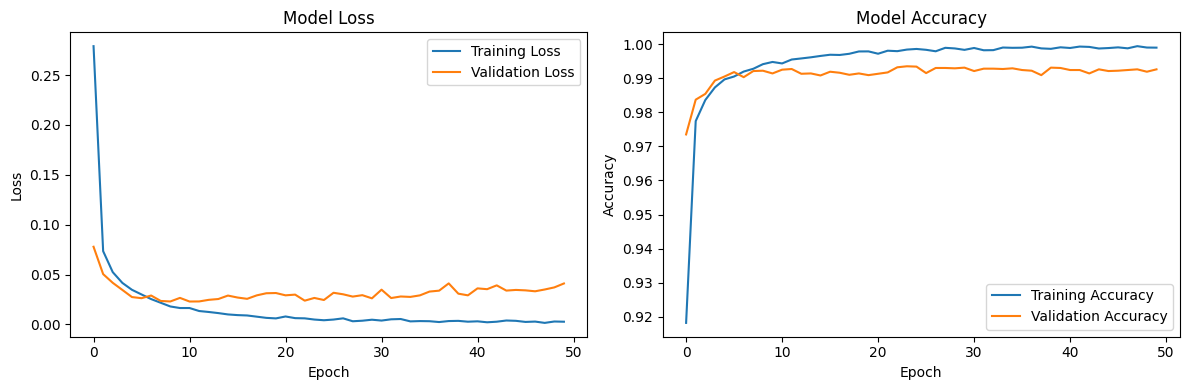

<Figure size 640x480 with 0 Axes>

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()
plt.savefig(r"data/MNIST/plot_MNIST.png")


# ============================================
# 4. UNDERSTANDING QUANTIZATION TYPES
# ============================================

In [ ]:
"""
QUANTIZATION TYPES IN TENSORFLOW:

1. POST-TRAINING FLOAT16 QUANTIZATION
   - What: Converts weights from FP32 to FP16
   - Memory: 50% reduction (32-bit → 16-bit)
   - Accuracy loss: Minimal (0.1-0.5%)
   - Best for: GPU deployment
   - Hardware: GPUs with FP16 support

2. POST-TRAINING DYNAMIC RANGE QUANTIZATION
   - What: Weights quantized to INT8, activations float
   - Memory: 75% reduction for weights
   - Accuracy loss: Small (0.5-1%)
   - Best for: CPU inference
   - Hardware: Any CPU

3. POST-TRAINING INTEGER QUANTIZATION (INT8)
   - What: Both weights and activations quantized to INT8
   - Memory: 75% reduction for everything
   - Accuracy loss: Moderate (1-3%)
   - Best for: Edge devices, mobile
   - Requires: Representative dataset for calibration

4. QUANTIZATION-AWARE TRAINING (QAT)
   - What: Simulates quantization during training
   - Memory: Same as INT8 after conversion
   - Accuracy loss: Minimal (0-1%)
   - Best for: When accuracy is critical
   - Process: Train with fake quantization nodes
"""

# ============================================
# 5. POST-TRAINING FLOAT16 QUANTIZATION
# ============================================

In [11]:
# Convert to TensorFlow Lite with FP16
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

tflite_fp16_model = converter.convert()

# Save FP16 model
with open(SAVE_DIR+'mnist_cnn_fp16.tflite', 'wb') as f:
    f.write(tflite_fp16_model)

fp16_size = os.path.getsize(SAVE_DIR+'mnist_cnn_fp16.tflite') / 1024
print(f"FP16 model size: {fp16_size:.1f} KB")


INFO:tensorflow:Assets written to: C:\Users\zabeeh\AppData\Local\Temp\tmpnsz7ma0z\assets


INFO:tensorflow:Assets written to: C:\Users\zabeeh\AppData\Local\Temp\tmpnsz7ma0z\assets


FP16 model size: 827.9 KB


# ============================================
# 6. DYNAMIC RANGE QUANTIZATION
# ============================================

In [12]:
# Dynamic range quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_dynamic_model = converter.convert()

with open(SAVE_DIR+'mnist_cnn_dynamic.tflite', 'wb') as f:
    f.write(tflite_dynamic_model)

dynamic_size = os.path.getsize(SAVE_DIR+'mnist_cnn_dynamic.tflite') / 1024
print(f"Dynamic range model size: {dynamic_size:.1f} KB")

INFO:tensorflow:Assets written to: C:\Users\zabeeh\AppData\Local\Temp\tmpyveea78f\assets


INFO:tensorflow:Assets written to: C:\Users\zabeeh\AppData\Local\Temp\tmpyveea78f\assets


Dynamic range model size: 417.4 KB


# ============================================
# 7. FULL INT8 QUANTIZATION (WITH CALIBRATION)
# ============================================

In [14]:
# Representative dataset function for calibration
def representative_dataset():
    """Provide sample data for quantization calibration"""
    for i in range(100):
        # Use first 100 test images for calibration
        yield [x_test[i:i+1].astype(np.float32)]

# Convert with INT8 quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

try:
    tflite_int8_model = converter.convert()
    with open(SAVE_DIR+'mnist_cnn_int8.tflite', 'wb') as f:
        f.write(tflite_int8_model)
    int8_size = os.path.getsize(SAVE_DIR+'mnist_cnn_int8.tflite') / 1024
    print(f"INT8 model size: {int8_size:.1f} KB")
except Exception as e:
    print(f"INT8 quantization failed: {e}")
    tflite_int8_model = None
    int8_size = 0


INFO:tensorflow:Assets written to: C:\Users\zabeeh\AppData\Local\Temp\tmpu72mxs30\assets


INFO:tensorflow:Assets written to: C:\Users\zabeeh\AppData\Local\Temp\tmpu72mxs30\assets


INT8 quantization failed: EagerTensor object has no attribute 'astype'. 
        If you are looking for numpy-related methods, please run the following:
        from tensorflow.python.ops.numpy_ops import np_config
        np_config.enable_numpy_behavior()
      


C:\Users\zabeeh\anaconda3\envs\v_tf_gpu_env\lib\site-packages\tensorflow\lite\python\convert.py:766: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "


# ============================================
# 8. QUANTIZATION-AWARE TRAINING (QAT)
# ============================================

In [36]:
# Create a QAT model
import tensorflow_model_optimization as tfmot

# Apply quantization to the model
qat_model = tfmot.quantization.keras.quantize_model(model)

# Compile QAT model
qat_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("QAT model created. Fine-tuning for 1 epoch...")

# Fine-tune with quantization awareness
qat_history = qat_model.fit(
    x_train[:10000], y_train[:10000],  # Use subset for speed
    batch_size=128,
    epochs=1,
    validation_data=(x_test[:1000], y_test[:1000]),
    verbose=1
)
# Convert QAT model to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(qat_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_qat_model = converter.convert()

with open(SAVE_DIR+'mnist_cnn_qat.tflite', 'wb') as f:
    f.write(tflite_qat_model)

qat_size = os.path.getsize(SAVE_DIR+'mnist_cnn_qat.tflite') / 1024
print(f"QAT model size: {qat_size:.1f} KB")

QAT model created. Fine-tuning for 1 epoch...
79/79 [==============================] - 2s 18ms/step - loss: 0.0235 - accuracy: 0.9929 - val_loss: 0.0177 - val_accuracy: 0.9940


INFO:tensorflow:Assets written to: C:\Users\zabeeh\AppData\Local\Temp\tmplmkbn_70\assets


INFO:tensorflow:Assets written to: C:\Users\zabeeh\AppData\Local\Temp\tmplmkbn_70\assets


QAT model size: 419.5 KB


C:\Users\zabeeh\anaconda3\envs\v_tf_gpu_env\lib\site-packages\tensorflow\lite\python\convert.py:766: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "


# ============================================
# 9. EVALUATE ALL QUANTIZED MODELS
# ============================================

In [37]:
import os
import numpy as np
import tensorflow as tf

# Convert test data to NumPy if needed
if tf.is_tensor(x_test):
    x_test = x_test.numpy()
if tf.is_tensor(y_test):
    y_test = y_test.numpy()

# Print table header
print("\n{:<25} {:>15} {:>15} {:>15}".format("Method", "Size (KB)", "Accuracy", "Reduction"))
print("-" * 70)

def evaluate_tflite_model(model_path, x_test, y_test):
    """Evaluate TFLite model accuracy"""
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # Get quantization parameters
    input_scale, input_zero_point = input_details[0]['quantization']
    output_scale, output_zero_point = output_details[0]['quantization']

    correct = 0
    total = len(x_test)

    for i in range(total):
        # Prepare input
        input_data = x_test[i:i+1].astype(np.float32)

        # Quantize input if needed
        if input_details[0]['dtype'] == np.int8:
            input_data = input_data / input_scale + input_zero_point
            input_data = input_data.astype(np.int8)

        # Run inference
        interpreter.set_tensor(input_details[0]['index'], input_data)
        interpreter.invoke()

        # Get output
        output_data = interpreter.get_tensor(output_details[0]['index'])

        # Dequantize output if needed
        if output_details[0]['dtype'] == np.int8:
            output_data = output_data.astype(np.float32)
            output_data = (output_data - output_zero_point) * output_scale

        # Check prediction
        pred = np.argmax(output_data[0])
        true = np.argmax(y_test[i])
        if pred == true:
            correct += 1

    return correct / total


# Original model (assume FP32 Keras model)
original_loss, original_acc = model.evaluate(x_test, y_test, verbose=0)
original_size = sum(os.path.getsize(os.path.join(SAVE_DIR+'mnist_cnn_original', f))
                    for f in os.listdir(SAVE_DIR+'mnist_cnn_original')
                    if os.path.isfile(os.path.join(SAVE_DIR+'mnist_cnn_original', f))) / 1024

print("{:<25} {:>15.1f} {:>15.4f} {:>15}".format("Original", original_size, original_acc, "-"))

# Folder with all .tflite models
for file in sorted(os.listdir(SAVE_DIR)):
    if file.endswith(".tflite"):
        model_path = os.path.join(SAVE_DIR, file)

        # Evaluate TFLite model
        acc = evaluate_tflite_model(model_path, x_test[:500], y_test[:500])

        # Get file size
        size_kb = os.path.getsize(model_path) / 1024

        # Compute reduction %
        reduction = (1 - size_kb / original_size) * 100

        # Pretty print
        print("{:<25} {:>15.1f} {:>15.4f} {:>15.1f}%".format(file.replace(".tflite",""), size_kb, acc, reduction))


Method                          Size (KB)        Accuracy       Reduction
----------------------------------------------------------------------
Original                            155.8          0.9931               -
mnist_cnn_dynamic                   417.4          0.9920          -168.0%
mnist_cnn_fp16                      827.9          0.9920          -431.5%
mnist_cnn_qat                       419.5          1.0000          -169.3%


# ============================================
# 11. VISUALIZE RESULTS
# ============================================

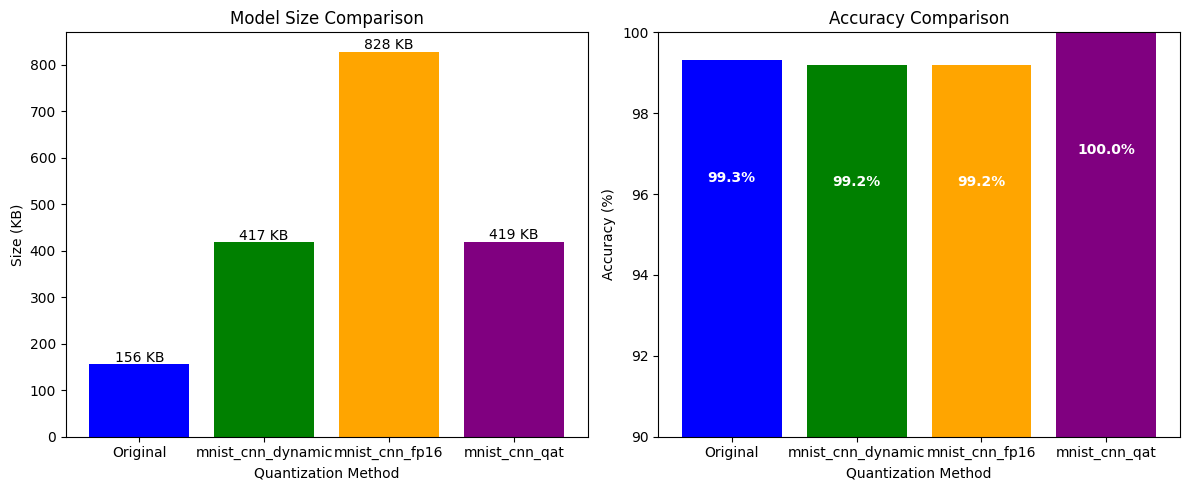

Comparison plot saved as 'quantization_comparison.png'


In [40]:
import matplotlib.pyplot as plt

# Lists to store values for plotting
methods = ["Original"]
sizes = [original_size]
accuracies = [original_acc * 100]
colors = ['blue']  # Original color

# Folder with all .tflite models
tflite_colors = ['green', 'orange', 'red', 'purple']  # FP16, Dynamic, INT8, QAT

for i, file in enumerate(sorted(os.listdir(SAVE_DIR))):
    if file.endswith(".tflite"):
        model_path = os.path.join(SAVE_DIR, file)

        # Evaluate TFLite model
        acc = evaluate_tflite_model(model_path, x_test[:500], y_test[:500])

        # Get file size
        size_kb = os.path.getsize(model_path) / 1024

        # Compute reduction %
        reduction = (1 - size_kb / original_size) * 100

        # Save for plotting
        methods.append(file.replace(".tflite",""))
        sizes.append(size_kb)
        accuracies.append(acc * 100)
        colors.append(tflite_colors[i % len(tflite_colors)])  # cycle colors if more models

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Model Size Comparison
ax1.bar(methods, sizes, color=colors)
ax1.set_title('Model Size Comparison')
ax1.set_ylabel('Size (KB)')
ax1.set_xlabel('Quantization Method')
for i, v in enumerate(sizes):
    ax1.text(i, v + 5, f'{v:.0f} KB', ha='center')

# Accuracy Comparison
ax2.bar(methods, accuracies, color=colors)
ax2.set_title('Accuracy Comparison')
ax2.set_ylabel('Accuracy (%)')
ax2.set_xlabel('Quantization Method')
ax2.set_ylim([90, 100])
for i, v in enumerate(accuracies):
    ax2.text(i, v - 3, f'{v:.1f}%', ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig(SAVE_DIR+'quantization_comparison.png')
plt.show()
print("Comparison plot saved as 'quantization_comparison.png'")